Using Colab cache for faster access to the 'telco-customer-churn' dataset.

=== Top rules (ALL) ===
ML=NoPhone → PS=No | supp=0.097 conf=1.000 lift=10.327 count=682
PS=No → ML=NoPhone | supp=0.097 conf=1.000 lift=10.327 count=682
IS=No → OS=NoNet | supp=0.217 conf=1.000 lift=4.615 count=1526
OS=NoNet → IS=No | supp=0.217 conf=1.000 lift=4.615 count=1526
IS=No → TS=NoNet | supp=0.217 conf=1.000 lift=4.615 count=1526
TS=NoNet → IS=No | supp=0.217 conf=1.000 lift=4.615 count=1526
OS=NoNet → TS=NoNet | supp=0.217 conf=1.000 lift=4.615 count=1526
TS=NoNet → OS=NoNet | supp=0.217 conf=1.000 lift=4.615 count=1526
ML=NoPhone → IS=DSL | supp=0.097 conf=1.000 lift=2.909 count=682
PS=No → IS=DSL | supp=0.097 conf=1.000 lift=2.909 count=682


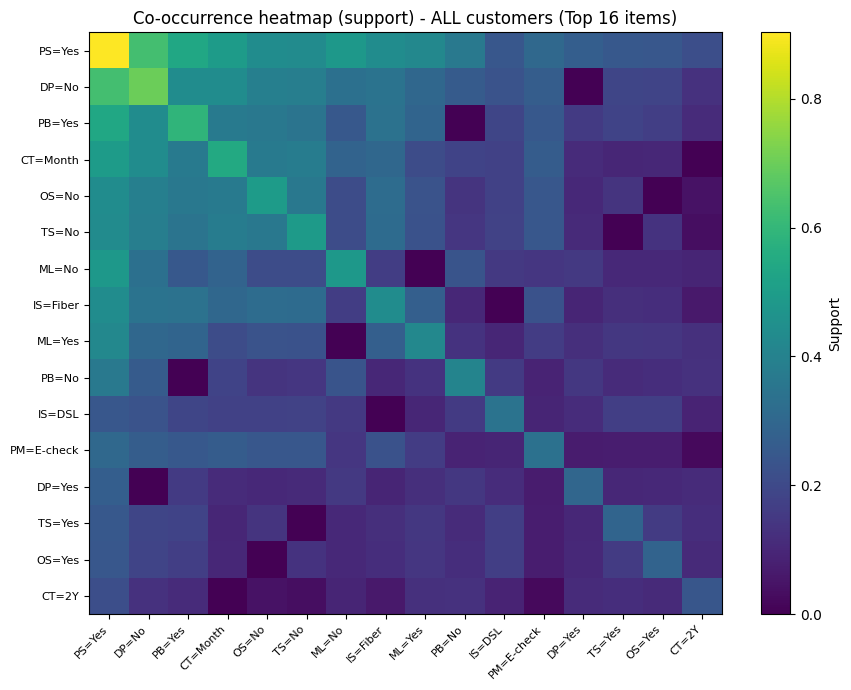

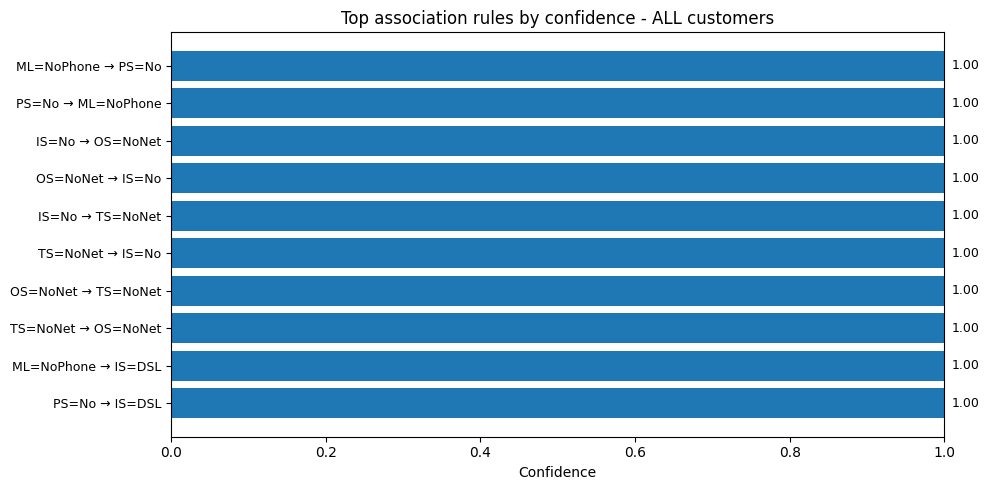


=== Top rules (CHURN=Yes) ===
ML=NoPhone → PS=No | supp=0.091 conf=1.000 lift=10.994 count=170
PS=No → ML=NoPhone | supp=0.091 conf=1.000 lift=10.994 count=170
ML=NoPhone → IS=DSL | supp=0.091 conf=1.000 lift=4.072 count=170
PS=No → IS=DSL | supp=0.091 conf=1.000 lift=4.072 count=170
IS=Fiber → PS=Yes | supp=0.694 conf=1.000 lift=1.100 count=1297
ML=Yes → PS=Yes | supp=0.455 conf=1.000 lift=1.100 count=850
ML=No → PS=Yes | supp=0.454 conf=1.000 lift=1.100 count=849
TS=No → CT=Month | supp=0.722 conf=0.934 lift=1.054 count=1350
DP=Yes → PS=Yes | supp=0.162 conf=0.929 lift=1.022 count=303
PM=E-check → CT=Month | supp=0.532 conf=0.928 lift=1.048 count=994


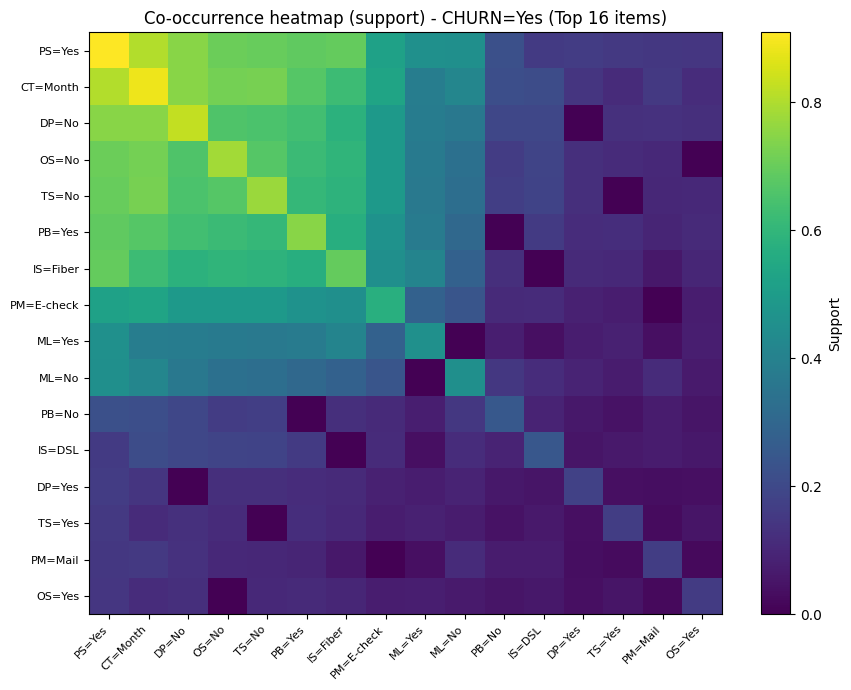

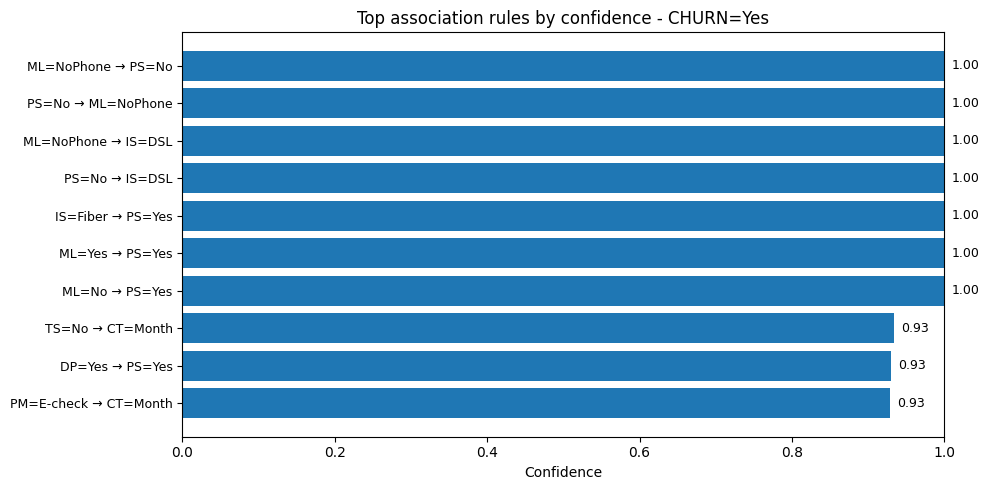


Dropped constant items in FIBER cohort: ['PS=Yes']

=== Top rules (Fiber optic cohort, excluding IS) ===
CT=Month → TS=No | supp=0.580 conf=0.844 lift=1.172 count=1796
CT=Month → DP=No | supp=0.575 conf=0.837 lift=1.065 count=1781
CT=Month → OS=No | supp=0.573 conf=0.834 lift=1.144 count=1774
PM=E-check → DP=No | supp=0.429 conf=0.832 lift=1.058 count=1327
PM=E-check → CT=Month | supp=0.422 conf=0.819 lift=1.192 count=1307
CT=2Y → ML=Yes | supp=0.113 conf=0.818 lift=1.307 count=351
PM=E-check → OS=No | supp=0.420 conf=0.816 lift=1.119 count=1301
TS=No → DP=No | supp=0.586 conf=0.813 lift=1.035 count=1814
OS=No → DP=No | supp=0.592 conf=0.812 lift=1.032 count=1832
PM=E-check → TS=No | supp=0.416 conf=0.808 lift=1.121 count=1288


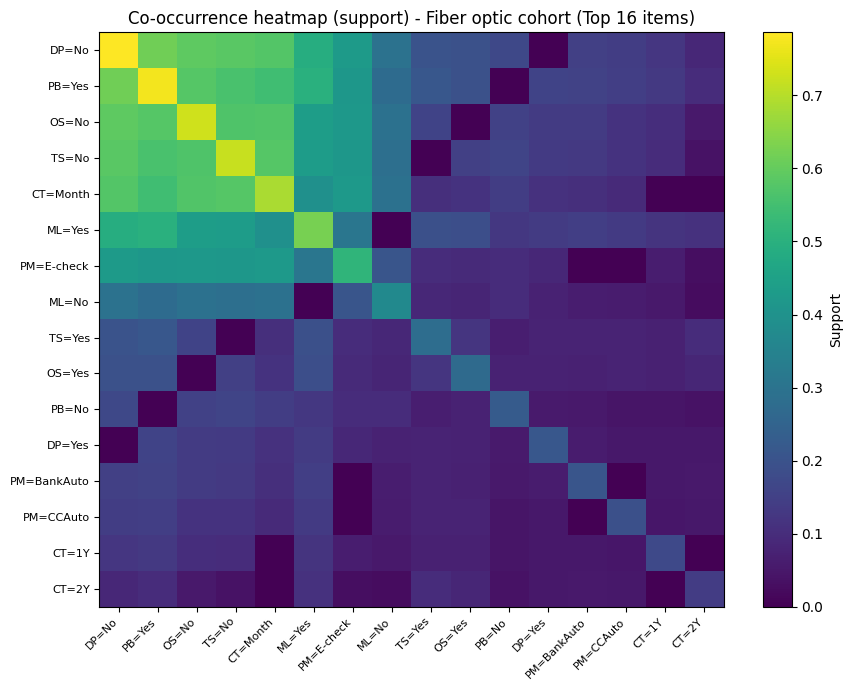

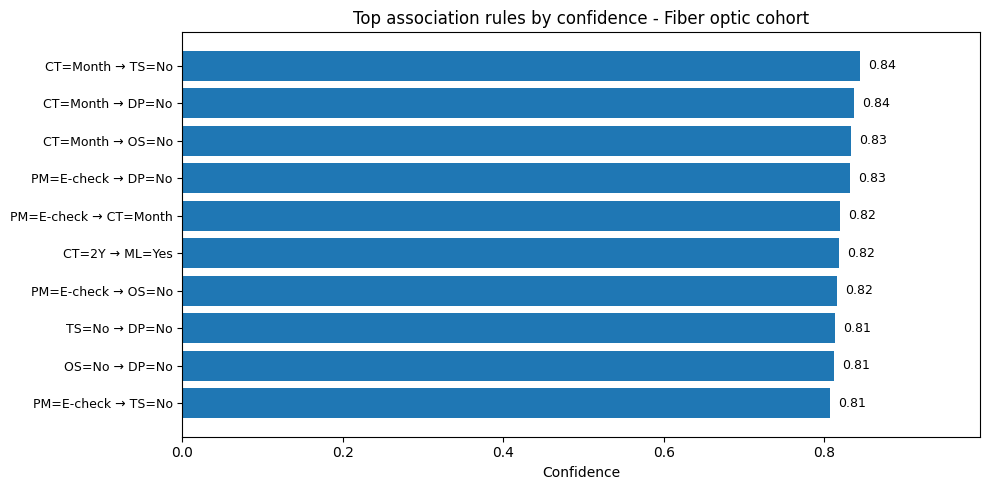


=== Label mapping sample (Top ALL heatmap items) ===
PS=Yes  <->  PhoneService=Yes
DP=No  <->  Dependents=No
PB=Yes  <->  PaperlessBilling=Yes
CT=Month  <->  Contract=Month-to-month
OS=No  <->  OnlineSecurity=No
TS=No  <->  TechSupport=No
ML=No  <->  MultipleLines=No
IS=Fiber  <->  InternetService=Fiber optic
ML=Yes  <->  MultipleLines=Yes
PB=No  <->  PaperlessBilling=No
IS=DSL  <->  InternetService=DSL
PM=E-check  <->  PaymentMethod=Electronic check
DP=Yes  <->  Dependents=Yes
TS=Yes  <->  TechSupport=Yes
OS=Yes  <->  OnlineSecurity=Yes
CT=2Y  <->  Contract=Two year


In [ ]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

# ============================================================
# 1) Find CSV path from kagglehub download (robust)
# ============================================================
def find_csv_file(root_dir: str, target_name: str):
    for base, _, files in os.walk(root_dir):
        for fn in files:
            if fn == target_name:
                return os.path.join(base, fn)
    raise FileNotFoundError(f"Cannot find {target_name} under {root_dir}")

# ============================================================
# 2) Abbreviation (short labels) + mapping for report
#    item: "InternetService=Fiber optic" -> "IS=Fiber"
# ============================================================
COL_ABBR = {
    "InternetService": "IS",
    "OnlineSecurity": "OS",
    "TechSupport": "TS",
    "Contract": "CT",
    "PaymentMethod": "PM",
    "PaperlessBilling": "PB",
    "Dependents": "DP",
    "PhoneService": "PS",
    "MultipleLines": "ML",
    "Churn": "CH",
}

VAL_ABBR = {
    "Fiber optic": "Fiber",
    "No internet service": "NoNet",
    "No phone service": "NoPhone",
    "Month-to-month": "Month",
    "One year": "1Y",
    "Two year": "2Y",
    "Electronic check": "E-check",
    "Mailed check": "Mail",
    "Bank transfer (automatic)": "BankAuto",
    "Credit card (automatic)": "CCAuto",
    "Yes": "Yes",
    "No": "No",
}

def abbrev_item(item: str) -> str:
    if "=" not in item:
        return item
    col, val = item.split("=", 1)
    col = col.strip()
    val = val.strip()
    c = COL_ABBR.get(col, col[:2].upper())
    v = VAL_ABBR.get(val, val.replace(" ", ""))
    return f"{c}={v}"

def abbrev_rule(a: str, b: str) -> str:
    return f"{abbrev_item(a)} → {abbrev_item(b)}"

def build_label_mapping(items):
    """
    Return dict: short -> full
    If collision happens (rare), keep first and append suffix for later ones.
    """
    mapping = {}
    used = set()
    for full in items:
        short = abbrev_item(full)
        if short not in used:
            mapping[short] = full
            used.add(short)
        else:
            # resolve collision by suffix
            k = 2
            while f"{short}_{k}" in used:
                k += 1
            mapping[f"{short}_{k}"] = full
            used.add(f"{short}_{k}")
    return mapping

# ============================================================
# 3) Build transactions: each customer -> set of "col=value"
#    - NO pandas
#    - exclude_cols: remove columns used for cohort definition to avoid trivial rules
# ============================================================
def load_transactions_telco(
    csv_path: str,
    cols,
    churn_col="Churn",
    include_churn_item=False,
    filter_fn=None,          # function(row_dict) -> bool
    exclude_cols=None,       # set/list of col names to exclude from items
):
    exclude_cols = set(exclude_cols or [])
    tx = []
    with open(csv_path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if filter_fn is not None and not filter_fn(row):
                continue

            items = set()
            for c in cols:
                if c in exclude_cols:
                    continue
                v = (row.get(c, "") or "").strip()
                if v == "":
                    continue
                items.add(f"{c}={v}")

            if include_churn_item:
                cv = (row.get(churn_col, "") or "").strip()
                if cv != "":
                    items.add(f"{churn_col}={cv}")

            if items:
                tx.append(items)
    return tx

# ============================================================
# 4) Counting supports for singletons and pairs
# ============================================================
def count_singletons_pairs(transactions):
    n = len(transactions)
    item_count = {}
    pair_count = {}

    for t in transactions:
        items = sorted(t)

        for a in items:
            item_count[a] = item_count.get(a, 0) + 1

        L = len(items)
        for i in range(L):
            for j in range(i + 1, L):
                p = (items[i], items[j])
                pair_count[p] = pair_count.get(p, 0) + 1

    return item_count, pair_count, n

def prune_items_by_support(transactions, drop_if_support_ge=0.999):
    """
    In a cohort, some items can become constant (~1.0 support),
    which creates trivial rules with confidence ~1.0.
    This function removes those constant items from all transactions.
    """
    item_count, _, n = count_singletons_pairs(transactions)
    to_drop = set()
    for it, c in item_count.items():
        supp = c / n
        if supp >= drop_if_support_ge:
            to_drop.add(it)

    if not to_drop:
        return transactions, to_drop

    new_tx = []
    for t in transactions:
        nt = set(x for x in t if x not in to_drop)
        if nt:
            new_tx.append(nt)
    return new_tx, to_drop

# ============================================================
# 5) Mine pair rules (A -> B) from frequent pairs
# ============================================================
def mine_pair_rules(transactions, min_support=0.05, min_conf=0.3):
    item_count, pair_count, n = count_singletons_pairs(transactions)

    rules = []
    for (a, b), c_ab in pair_count.items():
        supp_ab = c_ab / n
        if supp_ab < min_support:
            continue

        supp_a = item_count[a] / n
        supp_b = item_count[b] / n

        # a -> b
        conf_a_b = supp_ab / supp_a if supp_a > 0 else 0.0
        lift_a_b = conf_a_b / supp_b if supp_b > 0 else 0.0
        if conf_a_b >= min_conf:
            rules.append({
                "A": a, "B": b,
                "support": supp_ab,
                "confidence": conf_a_b,
                "lift": lift_a_b,
                "count_pair": c_ab
            })

        # b -> a
        conf_b_a = supp_ab / supp_b if supp_b > 0 else 0.0
        lift_b_a = conf_b_a / supp_a if supp_a > 0 else 0.0
        if conf_b_a >= min_conf:
            rules.append({
                "A": b, "B": a,
                "support": supp_ab,
                "confidence": conf_b_a,
                "lift": lift_b_a,
                "count_pair": c_ab
            })

    # sort by confidence, then lift, then support
    rules.sort(key=lambda x: (x["confidence"], x["lift"], x["support"]), reverse=True)
    return rules

# ============================================================
# 6) Co-occurrence heatmap matrix (support) for top_k items
# ============================================================
def build_cooccurrence_matrix(transactions, top_k=16):
    item_count, pair_count, n = count_singletons_pairs(transactions)

    items_sorted = sorted(item_count.items(), key=lambda x: x[1], reverse=True)
    top_items = [k for (k, _) in items_sorted[:top_k]]

    idx = {it: i for i, it in enumerate(top_items)}
    M = np.zeros((top_k, top_k), dtype=float)

    for it in top_items:
        i = idx[it]
        M[i, i] = item_count[it] / n

    for (a, b), c_ab in pair_count.items():
        if a in idx and b in idx:
            i, j = idx[a], idx[b]
            s_ab = c_ab / n
            M[i, j] = s_ab
            M[j, i] = s_ab

    return M, top_items

# ============================================================
# 7) Plot: heatmap with abbreviated labels
# ============================================================
def plot_heatmap_support(M, items_full, title, save_path=None):
    labels = [abbrev_item(x) for x in items_full]

    plt.figure(figsize=(9, 7))
    plt.imshow(M, aspect="auto")
    plt.title(title)
    plt.colorbar(label="Support")

    plt.xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(len(labels)), labels, fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

# ============================================================
# 8) Plot: top rules as horizontal bar chart (readable)
# ============================================================
def plot_top_rules(rules, top_n=10, title="Top association rules", save_path=None):
    top = rules[:top_n]
    labels = [abbrev_rule(r["A"], r["B"]) for r in top]
    values = [r["confidence"] for r in top]

    # horizontal bar is much more readable for long-ish labels
    plt.figure(figsize=(10, 5))
    y = np.arange(len(values))
    plt.barh(y, values)
    plt.yticks(y, labels, fontsize=9)
    plt.gca().invert_yaxis()
    plt.xlabel("Confidence")
    plt.title(title)

    # show numeric values
    for i, v in enumerate(values):
        plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

    plt.xlim(0, min(1.0, max(values) + 0.15))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

# ============================================================
# MAIN demo
# ============================================================
if __name__ == "__main__":
    root = kagglehub.dataset_download("blastchar/telco-customer-churn")
    csv_path = find_csv_file(root, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

    cols = [
        "InternetService",
        "OnlineSecurity",
        "TechSupport",
        "Contract",
        "PaymentMethod",
        "PaperlessBilling",
        "Dependents",
        "PhoneService",
        "MultipleLines",
    ]

    # --------------------------
    # Case A: All customers
    # --------------------------
    tx_all = load_transactions_telco(csv_path, cols, include_churn_item=False)

    # (optional) prune constants in ALL (usually none, but safe)
    tx_all, dropped_all = prune_items_by_support(tx_all, drop_if_support_ge=0.999)

    rules_all = mine_pair_rules(tx_all, min_support=0.05, min_conf=0.35)
    print("\n=== Top rules (ALL) ===")
    for r in rules_all[:10]:
        print(f"{abbrev_rule(r['A'], r['B'])} | supp={r['support']:.3f} conf={r['confidence']:.3f} lift={r['lift']:.3f} count={r['count_pair']}")

    M_all, items_all = build_cooccurrence_matrix(tx_all, top_k=16)
    plot_heatmap_support(
        M_all, items_all,
        title="Co-occurrence heatmap (support) - ALL customers (Top 16 items)",
        save_path="Fig_Assoc_Cooccur_ALL.png"
    )
    plot_top_rules(
        rules_all, top_n=10,
        title="Top association rules by confidence - ALL customers",
        save_path="Fig_Assoc_TopRules_ALL.png"
    )

    # --------------------------
    # Case B: Churn=Yes only (risk bundle)
    # --------------------------
    tx_churn = load_transactions_telco(
        csv_path, cols,
        include_churn_item=False,
        filter_fn=lambda row: (row.get("Churn", "") or "").strip() == "Yes"
    )

    # prune constant items inside churn cohort if any
    tx_churn, dropped_churn = prune_items_by_support(tx_churn, drop_if_support_ge=0.999)
    if dropped_churn:
        print("\nDropped constant items in CHURN cohort:", [abbrev_item(x) for x in sorted(dropped_churn)])

    rules_churn = mine_pair_rules(tx_churn, min_support=0.07, min_conf=0.35)
    print("\n=== Top rules (CHURN=Yes) ===")
    for r in rules_churn[:10]:
        print(f"{abbrev_rule(r['A'], r['B'])} | supp={r['support']:.3f} conf={r['confidence']:.3f} lift={r['lift']:.3f} count={r['count_pair']}")

    M_churn, items_churn = build_cooccurrence_matrix(tx_churn, top_k=16)
    plot_heatmap_support(
        M_churn, items_churn,
        title="Co-occurrence heatmap (support) - CHURN=Yes (Top 16 items)",
        save_path="Fig_Assoc_Cooccur_CHURN.png"
    )
    plot_top_rules(
        rules_churn, top_n=10,
        title="Top association rules by confidence - CHURN=Yes",
        save_path="Fig_Assoc_TopRules_CHURN.png"
    )

    # --------------------------
    # Case C: Fiber optic cohort
    # Key fix: exclude 'InternetService' from items to avoid trivial rules
    # --------------------------
    tx_fiber = load_transactions_telco(
        csv_path, cols,
        include_churn_item=False,
        filter_fn=lambda row: (row.get("InternetService", "") or "").strip() == "Fiber optic",
        exclude_cols={"InternetService"}   # IMPORTANT
    )

    # prune constants in fiber cohort if any
    tx_fiber, dropped_fiber = prune_items_by_support(tx_fiber, drop_if_support_ge=0.999)
    if dropped_fiber:
        print("\nDropped constant items in FIBER cohort:", [abbrev_item(x) for x in sorted(dropped_fiber)])

    rules_fiber = mine_pair_rules(tx_fiber, min_support=0.07, min_conf=0.35)
    print("\n=== Top rules (Fiber optic cohort, excluding IS) ===")
    for r in rules_fiber[:10]:
        print(f"{abbrev_rule(r['A'], r['B'])} | supp={r['support']:.3f} conf={r['confidence']:.3f} lift={r['lift']:.3f} count={r['count_pair']}")

    M_fiber, items_fiber = build_cooccurrence_matrix(tx_fiber, top_k=16)
    plot_heatmap_support(
        M_fiber, items_fiber,
        title="Co-occurrence heatmap (support) - Fiber optic cohort (Top 16 items)",
        save_path="Fig_Assoc_Cooccur_FIBER.png"
    )
    plot_top_rules(
        rules_fiber, top_n=10,
        title="Top association rules by confidence - Fiber optic cohort",
        save_path="Fig_Assoc_TopRules_FIBER.png"
    )

    # --------------------------
    # Optional: print mapping for report (Top heatmap items)
    # --------------------------
    print("\n=== Label mapping sample (Top ALL heatmap items) ===")
    mapping = build_label_mapping(items_all)
    for short, full in mapping.items():
        print(f"{short}  <->  {full}")

100%|██████████| 291M/291M [00:03<00:00, 90.1MB/s]

Extracting files...


events.csv: /root/.cache/kagglehub/datasets/retailrocket/ecommerce-dataset/versions/2/events.csv
Total view events: 2664312
Sessions used: 3776
Top items universe: 20

[Sequential] #frequent patterns: 16
Pattern: (461686,) | supp= 0.1115 | count= 421
Pattern: (219512,) | supp= 0.1107 | count= 418
Pattern: (461686, 461686) | supp= 0.1094 | count= 413
Pattern: (309778,) | supp= 0.0967 | count= 365
Pattern: (384302,) | supp= 0.0964 | count= 364
Pattern: (257040,) | supp= 0.089 | count= 336
Pattern: (187946, 187946) | supp= 0.0702 | count= 265
Pattern: (187946,) | supp= 0.0702 | count= 265
Pattern: (190000,) | supp= 0.0625 | count= 236
Pattern: (335975,) | supp= 0.0606 | count= 229


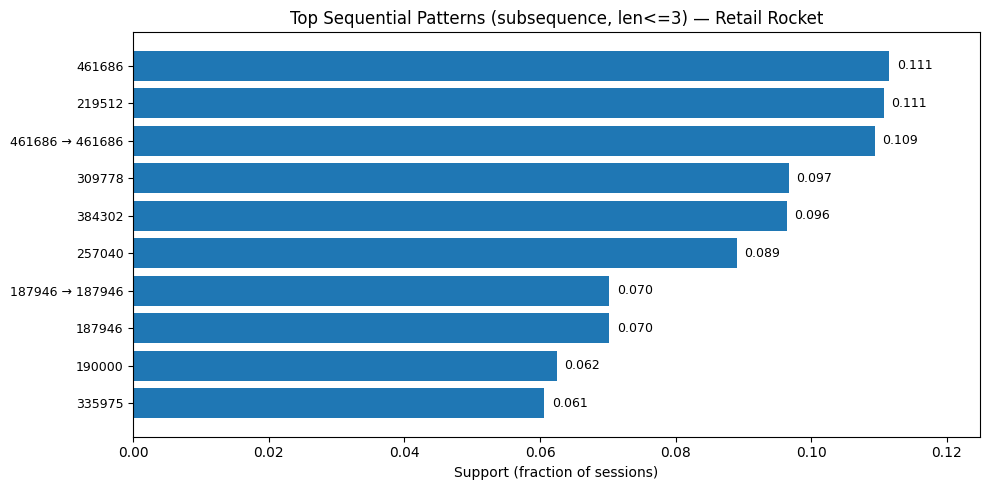


Global stream length (top items only): 32534
Windows evaluated: 3249

[Episode-Serial] Top 10 (A->B) by frequency
461686 -> 96924 | freq=0.6528
461686 -> 370653 | freq=0.6405
96924 -> 461686 | freq=0.6374
370653 -> 461686 | freq=0.6300
461686 -> 151444 | freq=0.6214
151444 -> 461686 | freq=0.6180
461686 -> 298009 | freq=0.6073
461686 -> 441668 | freq=0.6033
441668 -> 461686 | freq=0.5965
370653 -> 96924 | freq=0.5940

[Episode-Parallel] Top 10 ({A,B}) by frequency
{461686,96924} | freq=0.7655
{96924,461686} | freq=0.7655
{461686,151444} | freq=0.7371
{151444,461686} | freq=0.7371
{461686,370653} | freq=0.7365
{370653,461686} | freq=0.7365
{461686,441668} | freq=0.7196
{441668,461686} | freq=0.7196
{461686,298009} | freq=0.7094
{298009,461686} | freq=0.7094


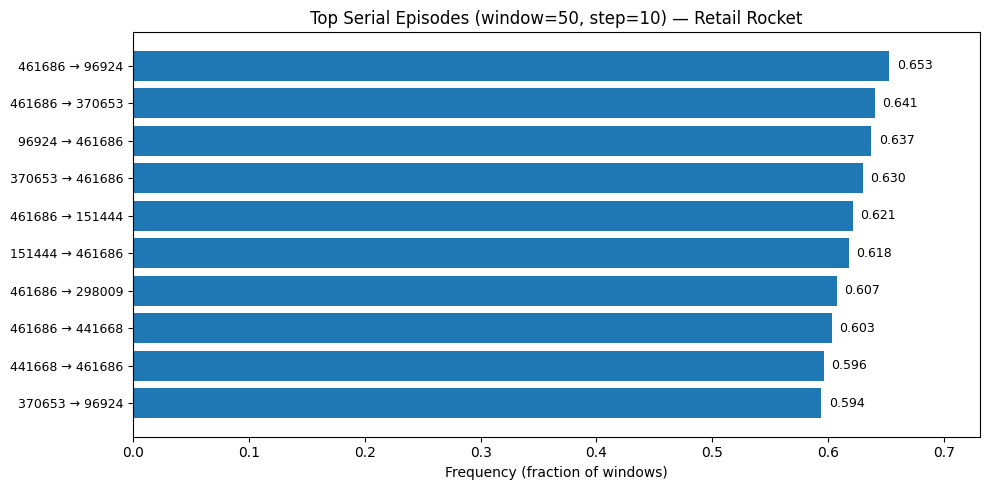

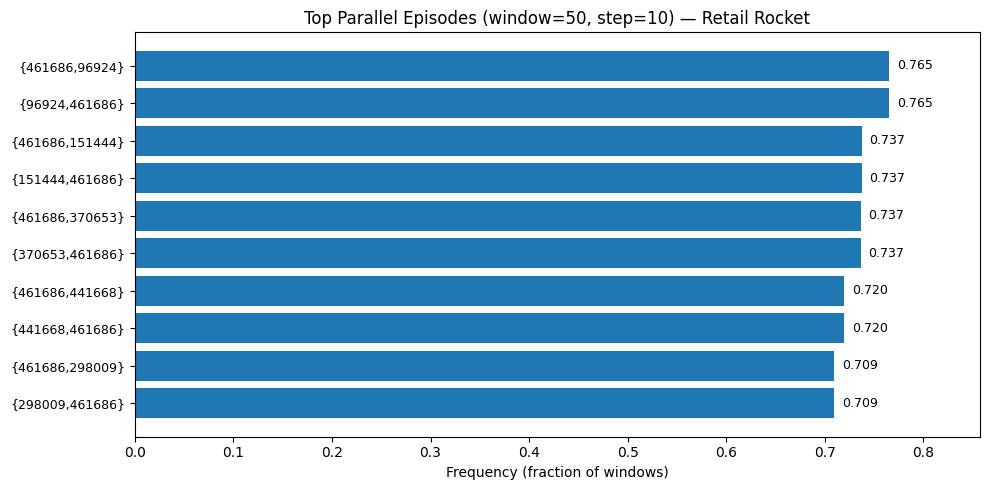


Saved figures:
- Fig_RR_Seq_TopPatterns.png
- Fig_RR_Episode_SerialTop.png
- Fig_RR_Episode_ParallelTop.png
Saved tables:
- Table_RR_Seq_Top10.csv
- Table_RR_Episode_SerialTop10.csv
- Table_RR_Episode_ParallelTop10.csv


In [ ]:
import os
import csv
import random
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt

# Optional: Kagglehub download
import kagglehub

# -----------------------------
# 0) Utils
# -----------------------------
def find_file(root_dir: str, target: str):
    for base, _, files in os.walk(root_dir):
        for fn in files:
            if fn == target:
                return os.path.join(base, fn)
    raise FileNotFoundError(f"Cannot find {target} under {root_dir}")

def read_events_csv(events_path: str, allowed_event_types=("view",)):
    """
    Read events.csv rows:
    timestamp,visitorid,event,itemid,transactionid
    We only keep: timestamp, visitorid, event, itemid
    """
    rows = []
    with open(events_path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            ev = (r.get("event") or "").strip()
            if allowed_event_types and ev not in allowed_event_types:
                continue
            try:
                ts = int(r["timestamp"])
                vid = int(r["visitorid"])
                iid = int(r["itemid"])
            except Exception:
                continue
            rows.append((ts, vid, ev, iid))
    return rows

def split_sessions_by_gap(sorted_events, gap_ms=30*60*1000):
    """
    Input: list of (ts, itemid) sorted by ts for ONE visitor
    Output: list of sessions, each session is list of itemids in time order
    Session break if time gap > gap_ms
    """
    sessions = []
    cur = []
    last_ts = None
    for ts, iid in sorted_events:
        if last_ts is not None and (ts - last_ts) > gap_ms:
            if len(cur) > 1:
                sessions.append(cur)
            cur = []
        cur.append(iid)
        last_ts = ts
    if len(cur) > 1:
        sessions.append(cur)
    return sessions

def barh_plot(labels, values, title, xlabel, save_path=None, top_pad=0.12):
    plt.figure(figsize=(10, 5))
    y = np.arange(len(values))
    plt.barh(y, values)
    plt.yticks(y, labels, fontsize=9)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)

    xmax = max(values) if values else 1.0
    plt.xlim(0, xmax * (1.0 + top_pad))
    for i, v in enumerate(values):
        plt.text(v + xmax * 0.01, i, f"{v:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

# -----------------------------
# 1) Sequential Pattern Mining (Prefix-extension, length <= 3)
#    - subsequence (không cần liên tiếp), không dùng pandas
# -----------------------------
def is_subsequence(pattern, seq):
    """
    pattern: tuple of item ids
    seq: list of item ids
    """
    j = 0
    for x in seq:
        if j < len(pattern) and x == pattern[j]:
            j += 1
            if j == len(pattern):
                return True
    return False

def mine_frequent_sequences(seqs, items_universe, min_support=0.02, max_len=3):
    """
    Simple candidate-generation:
    - start with length=1 from items_universe
    - extend by appending any item in items_universe
    Support = fraction of sequences containing pattern as subsequence.
    Return: list of (pattern_tuple, support, count)
    """
    N = len(seqs)
    if N == 0:
        return []

    results = []
    # level 1
    level = []
    for it in items_universe:
        cnt = sum(1 for s in seqs if is_subsequence((it,), s))
        supp = cnt / N
        if supp >= min_support:
            level.append((it,))
            results.append(((it,), supp, cnt))

    # extend
    k = 2
    while level and k <= max_len:
        next_level = []
        for pat in level:
            for it in items_universe:
                new_pat = pat + (it,)
                cnt = sum(1 for s in seqs if is_subsequence(new_pat, s))
                supp = cnt / N
                if supp >= min_support:
                    next_level.append(new_pat)
                    results.append((new_pat, supp, cnt))
        level = next_level
        k += 1

    # sort by support desc then length desc
    results.sort(key=lambda x: (x[1], len(x[0])), reverse=True)
    return results

# -----------------------------
# 2) Episode Mining (window-based on a global stream)
#    - Serial episode: A -> B (A occurs before B within window)
#    - Parallel episode: {A, B} (both occur within window, any order)
# -----------------------------
def build_global_stream(events_rows, top_items_set):
    """
    Build global stream (timestamp-sorted) as itemid list.
    Keep only itemid in top_items_set.
    """
    filtered = [(ts, iid) for (ts, _vid, _ev, iid) in events_rows if iid in top_items_set]
    filtered.sort(key=lambda x: x[0])
    return [iid for (_ts, iid) in filtered]

def episode_frequency_on_windows(stream, window_size=50, step=10, pairs=None):
    """
    stream: list itemids
    window_size: number of events per window
    step: slide step (#events)
    pairs: list of (a,b)
    Return:
      freq_serial[(a,b)] = fraction of windows where exists a before b
      freq_parallel[(a,b)] = fraction of windows where both appear
    """
    if pairs is None:
        pairs = []
    W = 0
    serial_hits = Counter()
    parallel_hits = Counter()

    L = len(stream)
    for start in range(0, max(0, L - window_size + 1), step):
        window = stream[start:start+window_size]
        W += 1

        pos = defaultdict(list)
        for idx, it in enumerate(window):
            pos[it].append(idx)

        for a, b in pairs:
            if a in pos and b in pos:
                parallel_hits[(a,b)] += 1
                # serial: exists i in pos[a], j in pos[b] with i < j
                if pos[a][0] < pos[b][-1]:
                    # Need strict check: there is some a-position < some b-position
                    # Equivalent: min(pos[a]) < max(pos[b])
                    if min(pos[a]) < max(pos[b]):
                        serial_hits[(a,b)] += 1

    freq_serial = {p: (serial_hits[p]/W if W else 0.0) for p in pairs}
    freq_parallel = {p: (parallel_hits[p]/W if W else 0.0) for p in pairs}
    return freq_serial, freq_parallel, W

# -----------------------------
# 3) MAIN: end-to-end demo
# -----------------------------
if __name__ == "__main__":
    # 3.1 Download dataset from Kaggle
    # Kaggle identifier from docs/books:
    # kaggle datasets download -d retailrocket/ecommerce-dataset
    root = kagglehub.dataset_download("retailrocket/ecommerce-dataset")
    events_path = find_file(root, "events.csv")
    print("events.csv:", events_path)

    # 3.2 Read events (views only for a clean behavioral signal)
    rows = read_events_csv(events_path, allowed_event_types=("view",))
    print("Total view events:", len(rows))

    # 3.3 Build visitor -> list of (ts, itemid)
    by_visitor = defaultdict(list)
    item_freq = Counter()
    for ts, vid, _ev, iid in rows:
        by_visitor[vid].append((ts, iid))
        item_freq[iid] += 1

    # 3.4 Choose top items to control search space (report-friendly)
    TOP_ITEMS = 20
    top_items = [iid for iid, _c in item_freq.most_common(TOP_ITEMS)]
    top_set = set(top_items)

    # 3.5 Build sessions (per visitor, split by gap)
    # Keep only top_set items, to reduce noise
    sessions = []
    for vid, evs in by_visitor.items():
        evs.sort(key=lambda x: x[0])
        evs = [(ts, iid) for (ts, iid) in evs if iid in top_set]
        if len(evs) < 2:
            continue
        ss = split_sessions_by_gap(evs, gap_ms=30*60*1000)
        sessions.extend(ss)

    # Optional: subsample sessions for speed (still stable for demo)
    random.seed(7)
    if len(sessions) > 5000:
        sessions = random.sample(sessions, 5000)

    print("Sessions used:", len(sessions))
    print("Top items universe:", len(top_items))

    # -------------------------
    # 6.2 Sequential Pattern Mining
    # -------------------------
    MIN_SUPP_SEQ = 0.05  # demo threshold
    MAX_LEN = 3
    seq_results = mine_frequent_sequences(
        seqs=sessions,
        items_universe=top_items,
        min_support=MIN_SUPP_SEQ,
        max_len=MAX_LEN
    )
    print("\n[Sequential] #frequent patterns:", len(seq_results))

    # Print top 10
    for pat, supp, cnt in seq_results[:10]:
        print("Pattern:", pat, "| supp=", round(supp, 4), "| count=", cnt)

    # Plot top patterns (convert item ids to short labels)
    topN = 10
    labels_seq = [" → ".join([str(x) for x in pat]) for (pat, _, _) in seq_results[:topN]]
    values_seq = [supp for (_, supp, _) in seq_results[:topN]]
    barh_plot(
        labels_seq, values_seq,
        title="Top Sequential Patterns (subsequence, len<=3) — Retail Rocket",
        xlabel="Support (fraction of sessions)",
        save_path="Fig_RR_Seq_TopPatterns.png"
    )

    # -------------------------
    # 6.3 Episode Mining
    # -------------------------
    # Build global stream from the same filtered events (top items only)
    stream = build_global_stream(rows, top_set)
    print("\nGlobal stream length (top items only):", len(stream))

    # Candidate episodes: all ordered pairs among top items
    pairs = []
    for i in range(len(top_items)):
        for j in range(len(top_items)):
            if i != j:
                pairs.append((top_items[i], top_items[j]))

    WINDOW_SIZE = 50
    STEP = 10
    freq_serial, freq_parallel, W = episode_frequency_on_windows(
        stream, window_size=WINDOW_SIZE, step=STEP, pairs=pairs
    )
    print("Windows evaluated:", W)

    # Rank top episodes
    top_serial = sorted(freq_serial.items(), key=lambda x: x[1], reverse=True)[:10]
    top_parallel = sorted(freq_parallel.items(), key=lambda x: x[1], reverse=True)[:10]

    print("\n[Episode-Serial] Top 10 (A->B) by frequency")
    for (a,b), fr in top_serial:
        print(f"{a} -> {b} | freq={fr:.4f}")

    print("\n[Episode-Parallel] Top 10 ({A,B}) by frequency")
    for (a,b), fr in top_parallel:
        print(f"{{{a},{b}}} | freq={fr:.4f}")

    # Plot top serial episodes
    labels_ser = [f"{a} → {b}" for ((a,b), _fr) in top_serial]
    values_ser = [fr for (_p, fr) in top_serial]
    barh_plot(
        labels_ser, values_ser,
        title=f"Top Serial Episodes (window={WINDOW_SIZE}, step={STEP}) — Retail Rocket",
        xlabel="Frequency (fraction of windows)",
        save_path="Fig_RR_Episode_SerialTop.png"
    )

    # Plot top parallel episodes
    labels_par = [f"{{{a},{b}}}" for ((a,b), _fr) in top_parallel]
    values_par = [fr for (_p, fr) in top_parallel]
    barh_plot(
        labels_par, values_par,
        title=f"Top Parallel Episodes (window={WINDOW_SIZE}, step={STEP}) — Retail Rocket",
        xlabel="Frequency (fraction of windows)",
        save_path="Fig_RR_Episode_ParallelTop.png"
    )

    # Save small tables to CSV for LaTeX import if needed
    with open("Table_RR_Seq_Top10.csv", "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["pattern", "support", "count"])
        for pat, supp, cnt in seq_results[:10]:
            w.writerow([" -> ".join(map(str, pat)), f"{supp:.6f}", cnt])

    with open("Table_RR_Episode_SerialTop10.csv", "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["A", "B", "frequency"])
        for (a,b), fr in top_serial:
            w.writerow([a, b, f"{fr:.6f}"])

    with open("Table_RR_Episode_ParallelTop10.csv", "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["A", "B", "frequency"])
        for (a,b), fr in top_parallel:
            w.writerow([a, b, f"{fr:.6f}"])

    print("\nSaved figures:")
    print("- Fig_RR_Seq_TopPatterns.png")
    print("- Fig_RR_Episode_SerialTop.png")
    print("- Fig_RR_Episode_ParallelTop.png")
    print("Saved tables:")
    print("- Table_RR_Seq_Top10.csv")
    print("- Table_RR_Episode_SerialTop10.csv")
    print("- Table_RR_Episode_ParallelTop10.csv")